# Bayesian Marketing Mix Modeling (MMM)
**Author:** Nishant Singh  
**Objective:** Estimate channel contributions, adstock carryover parameters, and ROI using PyMC Bayesian regression to optimize marketing budget allocation.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pymc as pm
import arviz as az

# Visual Styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print(f"PyMC Version: {pm.__version__}")
print(f"ArViz Version: {az.__version__}")

PyMC Version: 6.3.2
ArViz Version: 1.3.0


## 1. Data Loading & Inspection
Load the weekly sales and channel spend dataset, convert date fields, and check basic summary statistics.

In [5]:
# 1. Load Dataset
df = pd.read_csv("data/MMM_test_data.csv")

# 2. Parse dates explicitly to fix the UserWarning
df["start_of_week"] = pd.to_datetime(df["start_of_week"], format="mixed")
df = df.sort_values("start_of_week").reset_index(drop=True)

# 3. Identify spend columns
spend_cols = [col for col in df.columns if col.startswith('spend_channel_')]

print("--- Dataset Overview ---")
print(f"Timeframe: {df['start_of_week'].min().strftime('%Y-%m-%d')} to {df['start_of_week'].max().strftime('%Y-%m-%d')} ({len(df)} weeks)")
print(f"Missing Values: {df.isnull().sum().sum()}")
display(df.head())

--- Dataset Overview ---
Timeframe: 2020-01-11 to 2022-12-06 (104 weeks)
Missing Values: 0


,start_of_week,revenue,spend_channel_1,spend_channel_2,spend_channel_3,spend_channel_4,spend_channel_5,spend_channel_6,spend_channel_7
0,2020-01-11,213117.17,370.19,98.93,24509.24,4982.32,8945.98,7837.48,17768.76
1,2020-04-10,195581.04,3655.19,525.06,18024.45,9739.47,20804.05,25445.63,30394.41
2,2020-06-09,186425.68,2634.01,108.66,8760.28,4560.60,12747.70,12338.18,22473.45
3,2020-06-12,150423.19,1372.79,141.30,10183.94,7226.42,14808.32,14997.14,20745.24
4,2020-08-11,202321.02,1723.65,136.25,35550.52,4847.53,14683.10,12213.42,25127.60


## 2. Exploratory Data Analysis (EDA)
Examine revenue trends, weekly spend distribution across channels, and baseline correlations.

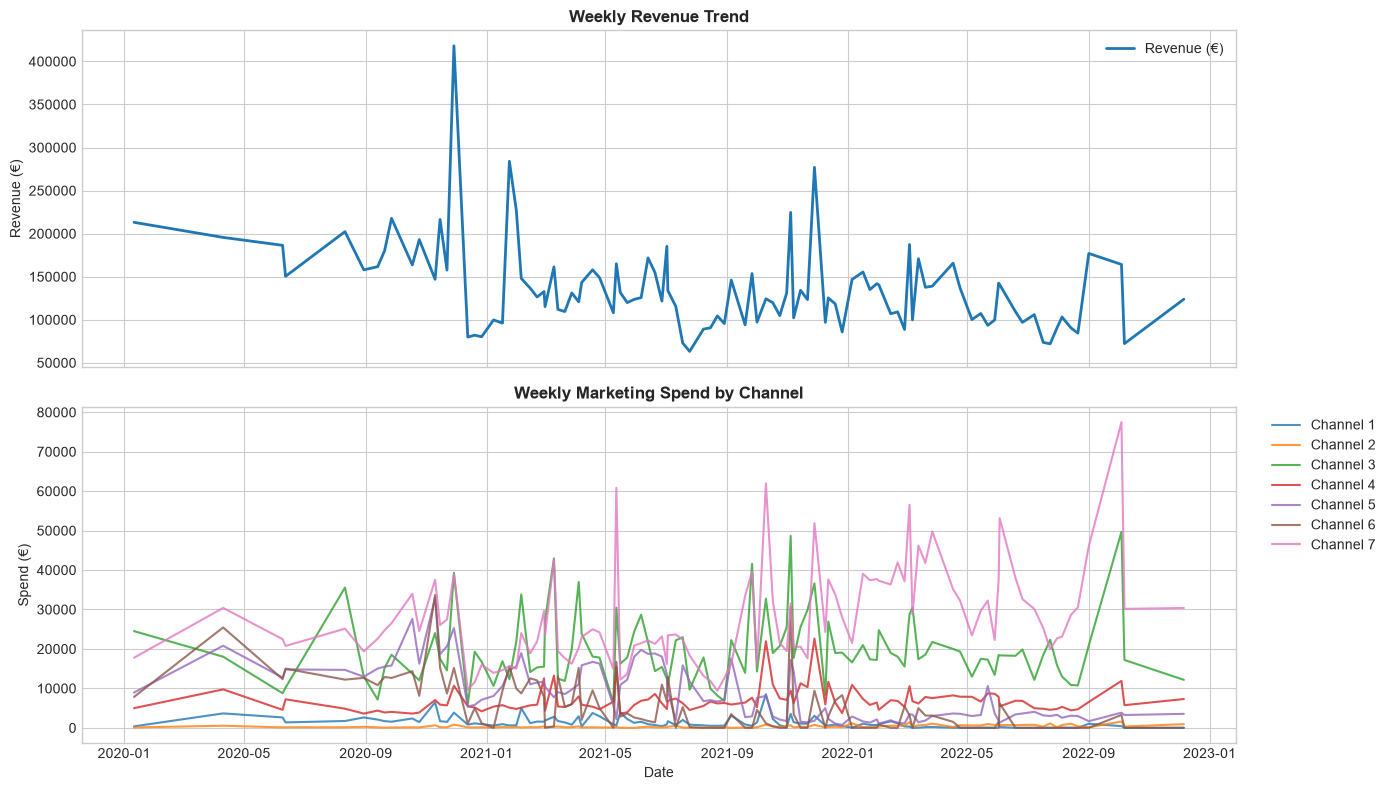

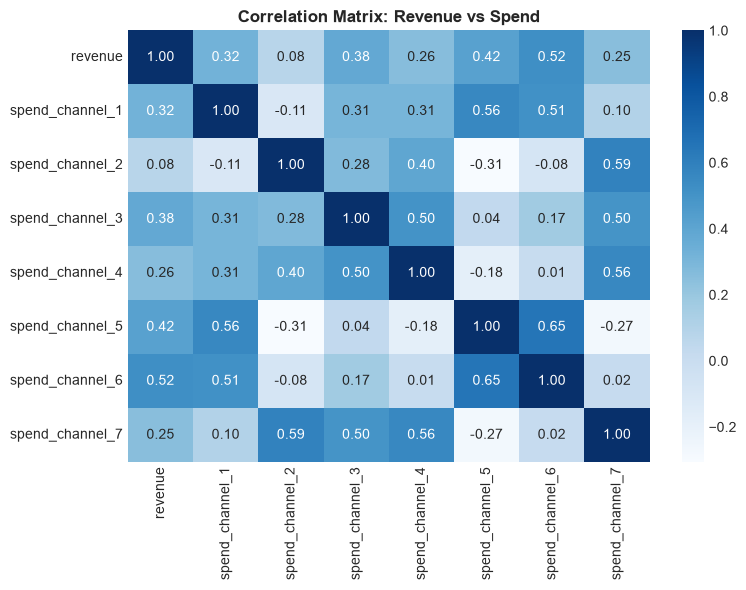

In [6]:
# 1. Weekly Revenue and Spend Trends
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df["start_of_week"], df["revenue"], color="#1f77b4", linewidth=2, label="Revenue (€)")
axes[0].set_title("Weekly Revenue Trend", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Revenue (€)")
axes[0].legend()

for col in spend_cols:
    axes[1].plot(df["start_of_week"], df[col], label=col.replace('spend_channel_', 'Channel '), alpha=0.8)

axes[1].set_title("Weekly Marketing Spend by Channel", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Spend (€)")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

# 2. Correlation Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(df[['revenue'] + spend_cols].corr(), annot=True, fmt=".2f", cmap="Blues")
plt.title("Correlation Matrix: Revenue vs Spend", fontweight="bold")
plt.tight_layout()
plt.show()